# Checkpoint 3 — ASR: Data Preparation and Analysis

**Datasets:**
- `LibriSpeech test-clean` — English, read speech, ~2620 clips, ~5.4h [15]
- `FLEURS ru_ru test` — Russian, read speech [16]

**Goals:**
1. Load both datasets and inspect raw format
2. Preprocess to unified format (16kHz, mono, PCM-16)
3. EDA: duration, transcript, speech rate, character set, amplitude
4. Save manifests for Checkpoint 4

**Dependencies:**
```
pip install datasets==2.18.0 librosa==0.10.1 soundfile==0.12.1 pandas==2.2.1 matplotlib==3.8.3 tqdm==4.66.2
```

## 0. Setup

Target format : 16 kHZ, mono, PCM_16

In [1]:
!pip install datasets==3.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [3]:
import os
import random
import unicodedata
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import soundfile as sf
import librosa
from datasets import load_dataset
from tqdm.auto import tqdm

In [4]:
SEED = 31122002
random.seed(SEED)
np.random.seed(SEED)

PROCESSED_DIR = Path("data/processed")
MANIFEST_DIR  = Path("data/manifests")
EDA_DIR = Path("eda/asr")
for d in [PROCESSED_DIR, MANIFEST_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16_000
TARGET_SUBTYPE = "PCM_16"
PEAK_TARGET = 0.9

## 1. Load Datasets

In [6]:
ls = load_dataset(
    "openslr/librispeech_asr",
    "clean",
    split="test",
    trust_remote_code=True,
)
print(len(ls))
print(ls.features)

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

clean/test/0000.parquet:   0%|          | 0.00/350M [00:00<?, ?B/s]

clean/train.100/0000.parquet:   0%|          | 0.00/470M [00:00<?, ?B/s]

clean/train.100/0001.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/2620 [00:00<?, ? examples/s]

Generating train.100 split:   0%|          | 0/28539 [00:00<?, ? examples/s]

Generating train.360 split:   0%|          | 0/104014 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2703 [00:00<?, ? examples/s]

2620
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'text': Value(dtype='string', id=None), 'speaker_id': Value(dtype='int64', id=None), 'chapter_id': Value(dtype='int64', id=None), 'id': Value(dtype='string', id=None)}


In [7]:
fl = load_dataset(
    "google/fleurs",
    "ru_ru",
    split="test",
    trust_remote_code=True,
)
print(len(fl))
print(fl.features)

README.md: 0.00B [00:00, ?B/s]

fleurs.py: 0.00B [00:00, ?B/s]

data/ru_ru/audio/train.tar.gz:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

data/ru_ru/audio/dev.tar.gz:   0%|          | 0.00/187M [00:00<?, ?B/s]

data/ru_ru/audio/test.tar.gz:   0%|          | 0.00/433M [00:00<?, ?B/s]

...

test.tsv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

775
{'id': Value(dtype='int32', id=None), 'num_samples': Value(dtype='int32', id=None), 'path': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'transcription': Value(dtype='string', id=None), 'raw_transcription': Value(dtype='string', id=None), 'gender': ClassLabel(names=['male', 'female', 'other'], id=None), 'lang_id': ClassLabel(names=['af_za', 'am_et', 'ar_eg', 'as_in', 'ast_es', 'az_az', 'be_by', 'bg_bg', 'bn_in', 'bs_ba', 'ca_es', 'ceb_ph', 'ckb_iq', 'cmn_hans_cn', 'cs_cz', 'cy_gb', 'da_dk', 'de_de', 'el_gr', 'en_us', 'es_419', 'et_ee', 'fa_ir', 'ff_sn', 'fi_fi', 'fil_ph', 'fr_fr', 'ga_ie', 'gl_es', 'gu_in', 'ha_ng', 'he_il', 'hi_in', 'hr_hr', 'hu_hu', 'hy_am', 'id_id', 'ig_ng', 'is_is', 'it_it', 'ja_jp', 'jv_id', 'ka_ge', 'kam_ke', 'kea_cv', 'kk_kz', 'km_kh', 'kn_in', 'ko_kr', 'ky_kg', 'lb_lu', 'lg_ug', 'ln_cd', 'lo_la', 'lt_lt', 'luo_ke', 'lv_lv', 'mi_nz', 'mk_mk', 'ml_in', 'mn_mn', 'mr_in', 'ms_my', 'mt_mt', 'my_mm', 'nb_no

In [8]:
s_ls = ls[10]
s_fl = fl[10]

print("LibriSpeech:")
print(f"SR: {s_ls['audio']['sampling_rate']} Hz")
print(f"audio len: {len(s_ls['audio']['array'])} samples")

print("\nFLEURS:")
print(f"SR: {s_fl['audio']['sampling_rate']} Hz")
print(f"audio len: {len(s_fl['audio']['array'])} samples")

LibriSpeech:
SR: 16000 Hz
audio len: 48560 samples

FLEURS:
SR: 16000 Hz
audio len: 241920 samples


## 2. Preprocessing Pipeline

All three ASR candidates (Whisper Large-v3, Parakeet-TDT-0.6B-v3, Whisper Turbo) expect:
- 16 000 Hz sample rate
- mono channel
- float32 input at inference time

We save as PCM-16 WAV on disk (lossless, half the size of float32).

In [9]:
def preprocess(array: np.ndarray, src_sr: int) -> np.ndarray:
    """
    Resample to 16kHz, convert to mono, peak-normalize.
    """
    y = array.astype(np.float32)
    if src_sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=src_sr, target_sr=TARGET_SR)
    if y.ndim > 1:
        y = librosa.to_mono(y)
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak * PEAK_TARGET
    return y

## 3. Build Manifests

For each clip we record:
- path to processed audio file on disk
- reference transcript
- language, duration, word count

This CSV is the direct input to the CP4 baseline notebook.

In [10]:
def build_manifest(
    dataset,
    transcript_key: str,
    language: str,
    prefix: str,
    out_dir: Path,
) -> pd.DataFrame:
    rows = []
    for i, sample in enumerate(tqdm(dataset, desc=f"{prefix}")):
        audio = sample["audio"]
        raw = np.array(audio["array"], dtype=np.float32)
        src_sr = audio["sampling_rate"]
        proc = preprocess(raw, src_sr)
        transcript = sample.get(transcript_key, "")
        fpath  = out_dir / f"{prefix}_{i:05d}.wav"
        fpath.parent.mkdir(parents=True, exist_ok=True)
        sf.write(str(fpath), proc, TARGET_SR, subtype=TARGET_SUBTYPE)
        rows.append({
            "id": f"{prefix}_{i:05d}",
            "audio_path": str(fpath),
            "transcript": transcript,
            "language": language,
            "duration_sec": round(len(proc) / TARGET_SR, 4),
            "n_words": len(transcript.split()),
            "n_chars": len(transcript),
            "orig_sr": src_sr,
        })
    return pd.DataFrame(rows)

In [11]:
m_ls = build_manifest(ls, "text", "en", "ls", PROCESSED_DIR / "librispeech_test_clean")
m_fl = build_manifest(fl, "transcription", "ru", "fl_ru", PROCESSED_DIR / "fleurs_ru_test")

m_ls.to_csv(MANIFEST_DIR / "asr_librispeech_test_clean.csv", index=False)
m_fl.to_csv(MANIFEST_DIR / "asr_fleurs_ru_test.csv", index=False)

ls:   0%|          | 0/2620 [00:00<?, ?it/s]

fl_ru:   0%|          | 0/775 [00:00<?, ?it/s]

## 4. EDA — Duration

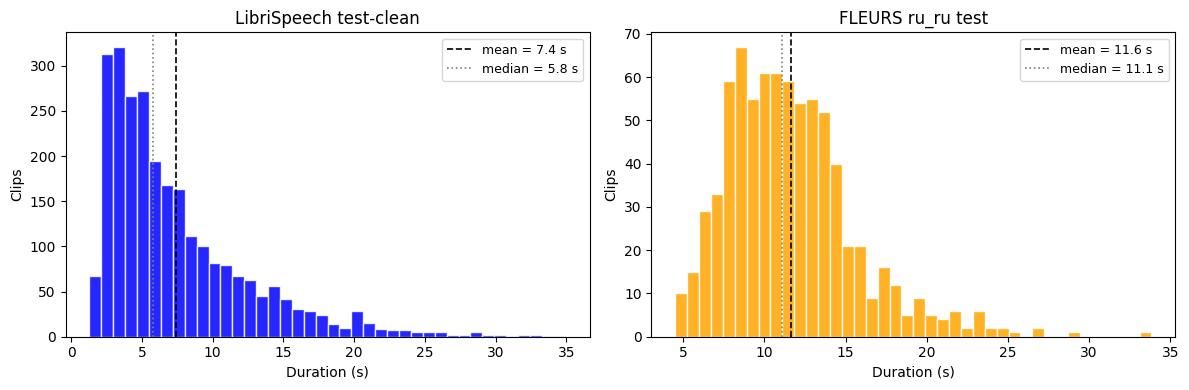

In [12]:
datasets_plot = [
    (m_ls, "LibriSpeech test-clean", "blue"),
    (m_fl, "FLEURS ru_ru test", "orange"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, title, color) in zip(axes, datasets_plot):
    d = df["duration_sec"]
    ax.hist(d, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(d.mean(),   color="black", linestyle="--", lw=1.2, label=f"mean = {d.mean():.1f} s")
    ax.axvline(d.median(), color="grey",  linestyle=":",  lw=1.2, label=f"median = {d.median():.1f} s")
    ax.set_title(title)
    ax.set_xlabel("Duration (s)")
    ax.set_ylabel("Clips")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "01_duration.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
for df, name in [(m_ls, "LibriSpeech"), (m_fl, "FLEURS-ru")]:
    short = (df["duration_sec"] < 1.0).sum()
    long  = (df["duration_sec"] > 30.0).sum()
    total = len(df)
    print(f"{name}:")
    print(f"total clips: {total:,}")
    print(f"total hours: {df['duration_sec'].sum() / 3600:.2f} h")
    print(f"< 1 s: {short}  ({100*short/total:.1f}%)")
    print(f"> 30 s: {long}   ({100*long/total:.1f}%)")

LibriSpeech:
total clips: 2,620
total hours: 5.40 h
< 1 s: 0  (0.0%)
> 30 s: 9   (0.3%)
FLEURS-ru:
total clips: 775
total hours: 2.50 h
< 1 s: 0  (0.0%)
> 30 s: 1   (0.1%)


## 5. EDA — Transcript

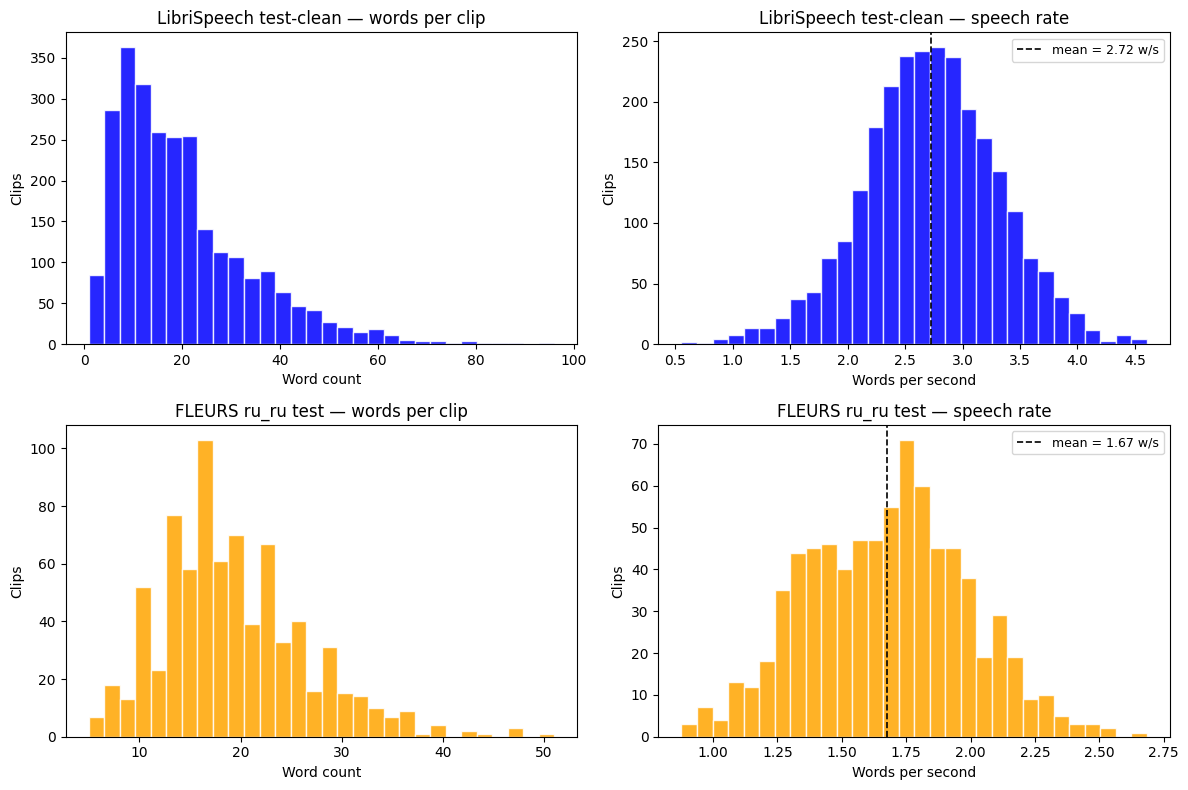

In [14]:
for df, name in [(m_ls, "LibriSpeech"), (m_fl, "FLEURS-ru")]:
    df["words_per_sec"] = df["n_words"] / df["duration_sec"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (df, name, color) in enumerate(datasets_plot):
    axes[row][0].hist(df["n_words"], bins=30, color=color, edgecolor="white", alpha=0.85)
    axes[row][0].set_title(f"{name} — words per clip")
    axes[row][0].set_xlabel("Word count")
    axes[row][0].set_ylabel("Clips")

    wps = df["words_per_sec"]
    axes[row][1].hist(wps, bins=30, color=color, edgecolor="white", alpha=0.85)
    axes[row][1].axvline(wps.mean(), color="black", linestyle="--", lw=1.2,
                         label=f"mean = {wps.mean():.2f} w/s")
    axes[row][1].set_title(f"{name} — speech rate")
    axes[row][1].set_xlabel("Words per second")
    axes[row][1].set_ylabel("Clips")
    axes[row][1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "02_transcript.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. EDA — Character Set

Important for Russian:
Parakeet-TDT may normalize ё to е in its output.
  If so, the same normalization must be applied to FLEURS references before computing WER/CER.
  Otherwise CER will be artificially inflated.

In [30]:
def char_category_report(df: pd.DataFrame, name: str):
    text = " ".join(df["transcript"].dropna())
    freq = Counter(text)
    cats = {"letter": 0, "digit": 0, "punctuation": 0, "space": 0, "other": 0}
    unusual = Counter()
    for ch, cnt in freq.items():
        cat = unicodedata.category(ch)
        if cat.startswith("L"):
            cats["letter"] += cnt
        elif cat.startswith("N"):
            cats["digit"] += cnt
        elif cat.startswith("P"):
            cats["punctuation"] += cnt
        elif cat.startswith("Z") or ch in " \t\n":
            cats["space"] += cnt
        else:
            cats["other"] += cnt
            unusual[ch] += cnt

    total = sum(cats.values())
    print(f"\n{name}:")
    for cat, cnt in cats.items():
        print(f"{cat}: {cnt}  ({100*cnt/total:.1f}%)")
    if unusual:
        print(f"unusual: {dict(unusual.most_common(10))}")


char_category_report(m_ls, "LibriSpeech EN")
char_category_report(m_fl, "FLEURS RU")


LibriSpeech EN:
letter: 231030  (81.3%)
digit: 0  (0.0%)
punctuation: 544  (0.2%)
space: 52575  (18.5%)
other: 0  (0.0%)

FLEURS RU:
letter: 90930  (85.1%)
digit: 664  (0.6%)
punctuation: 241  (0.2%)
space: 14968  (14.0%)
other: 1  (0.0%)
unusual: {'№': 1}


In [16]:
ru_text = " ".join(m_fl["transcript"].dropna())
yo_count = ru_text.count("ё") + ru_text.count("Ё")
total = len(ru_text)

In [17]:
def plot_char_freq(df: pd.DataFrame, name: str, color: str, ax, top_n: int = 30):
    text = " ".join(df["transcript"].dropna())
    freq = Counter(c for c in text if not c.isspace())
    most_common = freq.most_common(top_n)
    n = len(most_common)
    chars, counts = zip(*most_common)
    ax.bar(range(n), counts, color=color, edgecolor="white", alpha=0.85)
    ax.set_xticks(range(n))
    ax.set_xticklabels(chars, fontsize=9)
    ax.set_title(f"{name} — top {n} characters")
    ax.set_ylabel("Frequency")

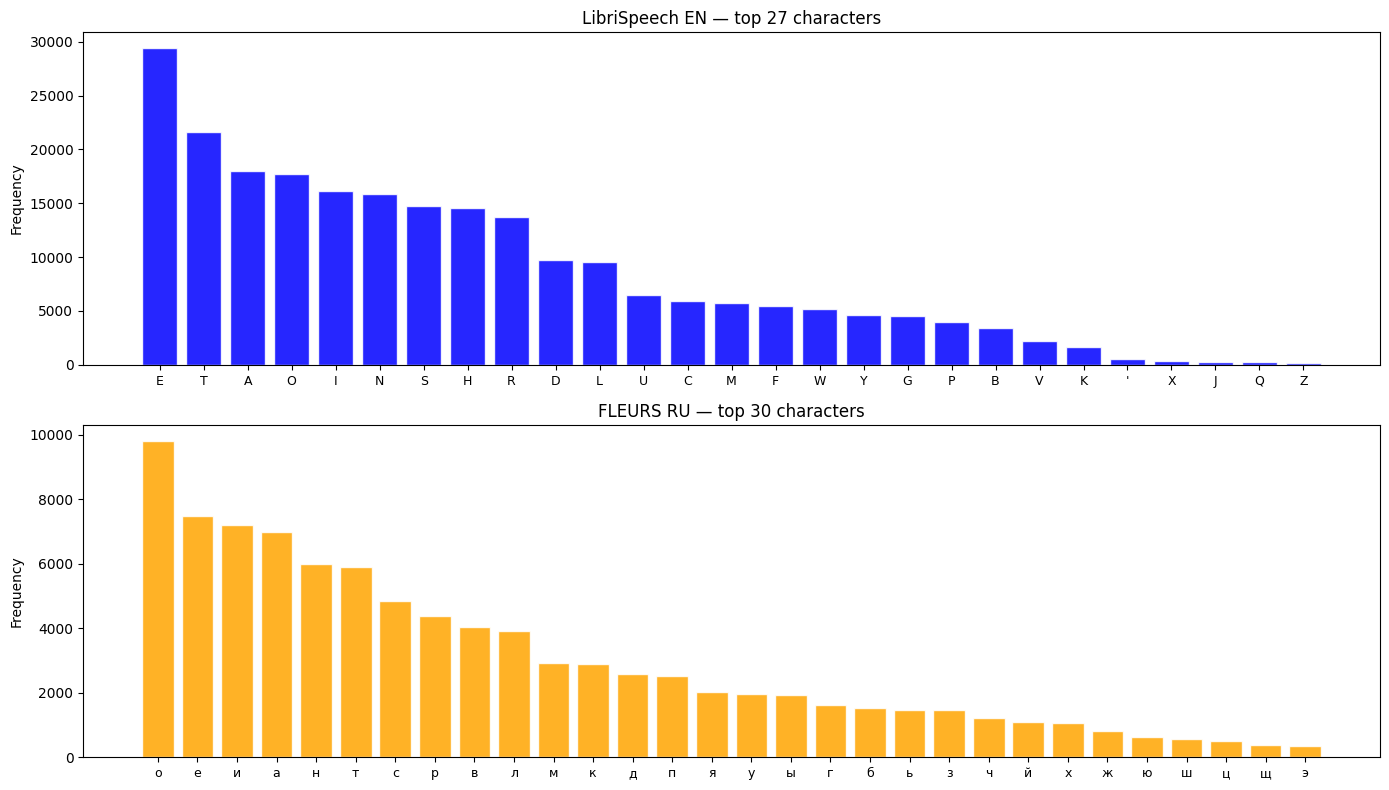

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_char_freq(m_ls, "LibriSpeech EN", "blue",  axes[0])
plot_char_freq(m_fl, "FLEURS RU", "orange", axes[1])
plt.tight_layout()
plt.savefig(EDA_DIR / "03_character_freq.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. EDA — Amplitude

Near-silent clips (RMS < 0.01) risk producing empty or hallucinated ASR output.
We check the raw signal **before preprocessing** to catch source-level issues.

In [19]:
def collect_amplitude_stats(dataset, transcript_key: str, desc: str) -> pd.DataFrame:
    rows = []
    for sample in tqdm(dataset, desc=desc):
        arr = np.array(sample["audio"]["array"], dtype=np.float32)
        rows.append({
            "peak": float(np.max(np.abs(arr))),
            "rms" : float(np.sqrt(np.mean(arr ** 2))),
        })
    return pd.DataFrame(rows)

In [20]:
amp_ls = collect_amplitude_stats(ls, "text", "LibriSpeech amplitude")
amp_fl = collect_amplitude_stats(fl, "transcription", "FLEURS amplitude")

LibriSpeech amplitude:   0%|          | 0/2620 [00:00<?, ?it/s]

FLEURS amplitude:   0%|          | 0/775 [00:00<?, ?it/s]

In [21]:
SILENCE_THRESHOLD = 0.01

LibriSpeech: near-silent clips (RMS < 0.01) = 0
FLEURS-ru: near-silent clips (RMS < 0.01) = 200


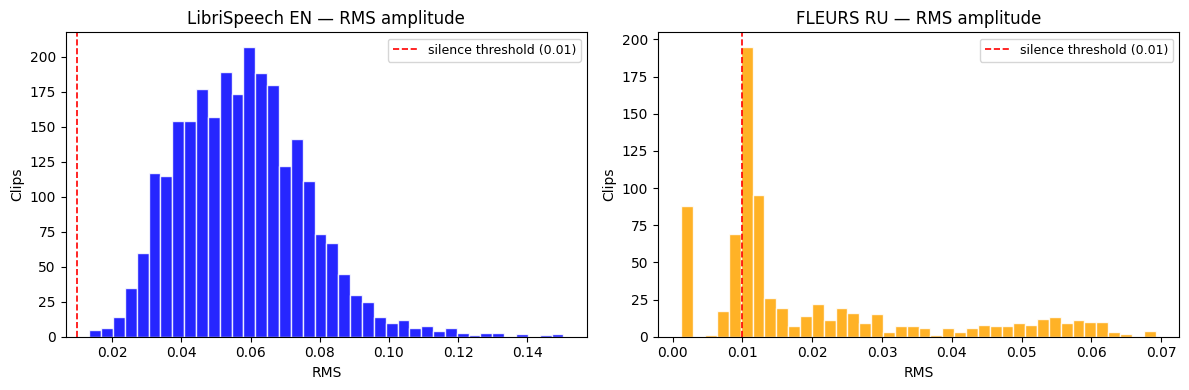

In [22]:
for amp, name in [(amp_ls, "LibriSpeech"), (amp_fl, "FLEURS-ru")]:
    silent = (amp["rms"] < SILENCE_THRESHOLD).sum()
    print(f"{name}: near-silent clips (RMS < {SILENCE_THRESHOLD}) = {silent}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (amp, name, color) in zip(axes, [
    (amp_ls, "LibriSpeech EN", "blue"),
    (amp_fl, "FLEURS RU", "orange"),
]):
    ax.hist(amp["rms"], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(SILENCE_THRESHOLD, color="red", linestyle="--", lw=1.2,
               label=f"silence threshold ({SILENCE_THRESHOLD})")
    ax.set_title(f"{name} — RMS amplitude")
    ax.set_xlabel("RMS")
    ax.set_ylabel("Clips")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "04_amplitude.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Dataset Summary Table

In [23]:
rows = []
for df, name, lang in [
    (m_ls, "LibriSpeech test-clean", "English"),
    (m_fl, "FLEURS ru_ru test",      "Russian"),
]:
    rows.append({
        "Dataset": name,
        "Language": lang,
        "# Clips": len(df),
        "Total hours": round(df["duration_sec"].sum() / 3600, 2),
        "Duration mean": round(df["duration_sec"].mean(), 2),
        "Duration min" : round(df["duration_sec"].min(), 2),
        "Duration max": round(df["duration_sec"].max(), 2),
        "Clips < 1s": int((df["duration_sec"] < 1).sum()),
        "Clips > 30s": int((df["duration_sec"] > 30).sum()),
        "Words mean": round(df["n_words"].mean(), 1),
    })

summary = pd.DataFrame(rows).set_index("Dataset")
print(summary.T.to_string())
summary.to_csv(MANIFEST_DIR / "asr_dataset_summary.csv")

Dataset       LibriSpeech test-clean FLEURS ru_ru test
Language                     English           Russian
# Clips                         2620               775
Total hours                      5.4               2.5
Duration mean                   7.42              11.6
Duration min                    1.28               4.5
Duration max                   34.95             33.84
Clips < 1s                         0                 0
Clips > 30s                        9                 1
Words mean                      20.1              19.3
